# Assignment 2: Interpolation de Lagrange

On considère la fonction $$f(x) = 1 + h(g(x)) \qquad \qquad \text{avec} \ \ h(y) = \dfrac{1}{1+2y+2y^2} \ \ \text{et} \ \ g(x) = \dfrac{x^2 - 2}{2}$$
sur l'intervalle $I=[-4.5,5.5]$.

1) Calculer le polynôme d'interpolation $\Pi_n f(x)$ de degré $n=15$ 

* avec des noeuds équidistribués
* avec les noeuds de Chebyshev 
    
Comparer graphiquement les résultats avec la fonction donnée. Puis, évaluer les erreurs d'interpolation

* $E^a_n(f)=\max\limits_{x\in I} \vert f(x) - \Pi_nf(x)\vert$ (*erreur absolue*)
* $E^r_n(f)=\max\limits_{x\in I} \dfrac{\vert f(x) - \Pi_nf(x)\vert}{\vert f(x) \vert}$ (*erreur relative*)

et visualiser le graphe logarithmique de l'erreur absolue $E^a_n$ en fonction de $n$ pour les noeuds équirépartis et pour le noeuds de Chebyshev, pour $n=5,\dots,50$. *Suggestion: faire une boucle et pour chaque itération comparer la fonction interpolée avec l'originale*. 

2) Calculer les polynômes interpolatoires linéaire $\Pi_1^H f(x)$ et quadratique $\Pi_2^H f(x)$ par intervalles, sur $N$ sous-intervalles de longeur $H=\frac{10}{N}$, avec $N=5,10,20,40$ et comparer graphiquement les résultats obtenus avec la fonction donnée. Prendre $N=5,\dots,50$ et évaluer les erreurs

* $E^a_H(f)=\max\limits_{x\in I} \vert f(x) - \Pi_1^H f(x)\vert$ (*erreur absolue*)
* $E^r_H(f)=\max\limits_{x\in I} \dfrac{\vert f(x) - \Pi_1^H f(x)\vert}{\vert f(x)\vert}$ (*erreur relative*)

Visualiser les graphes logarithmiques des erreures absolues $E^a_H$ en fonction du nombre d'intervalles $N$ pour les deux méthodes.

3) Comparer et commenter les résultats obtenus avec les differents méthodes. En particulier:

* Qu'est-ce qui se passe en utilisant des noeuds équidistribués? Pourquoi?
* Est-ce que l'erreur diminue en considerant des noeuds differents? Pourquoi?
* Est-ce que l'erreur diminue en utilisant l'interpolation par intervalles? Pourquoi?
* Quelle(s) méthode(s) choisisseriez-vous pour interpoler la fonction donnée avec une **erreur relative** au plus de 5%? Pourquoi?

4) **[Bonus]** Evaluez la fonction donnée en 101 points équidistribués sur $I$. Ensuite approchez la fonction avec la méthode des moindres carrées de degré $m=0,1,5,10,20,30,40,50$. 

**Aide**: *les fonctions pour l'interpolation de Lagrange, l'interpolation par intervalles et la construction de la matrice de Vandermonde se trouvent dans le fichier InterpolationLib.py et peuvent donc etre utilisées dans le code*. ***Vous pouvez télécharger le fichier mise à jour sur [Moodle](https://moodle.epfl.ch/course/view.php?id=7131) (semaine 14 March - 20 March).***

In [1]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt

from InterpolationLib import LagrangeInterpolation
from InterpolationLib import PiecewiseLinearInterpolation, PiecewiseQuadraticInterpolation
from InterpolationLib import VandermondeMatrix

La fonction $f$ peut être définie dans Python comme suit. 

In [2]:
g = lambda x : (x**2 - 2) / 2
h = lambda y : 1 / (1 + 2*y + 2*y**2 )
f = lambda x : 1 + h(g(x))

On va aussi avoir besoin des fonctions suivantes:

### Partie 1

Tracer le graphe de la fonction et de son polynôme d'interpolation de degré $n=15$ avec des noeuds équidistribués.

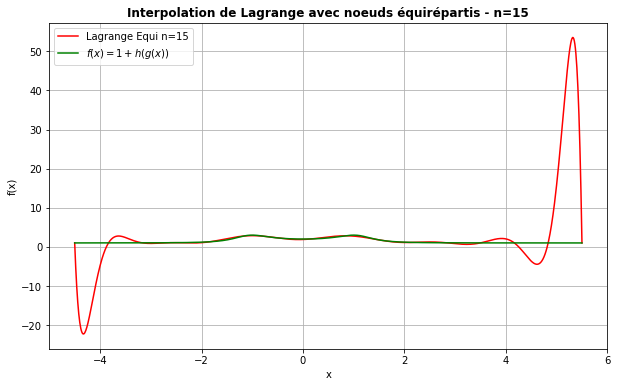

In [8]:
a = -4.5; b = 5.5
x = np.linspace(a,b,1000) # fine partition, for nice plotting 
n=15

# >>> COMPLETE HERE <<<
t = np.linspace(a,b,n+1)
fn = LagrangeInterpolation(t,f(t),x)

plt.figure(figsize=(10,6))
plt.plot(x, fn ,'r', x, f(x), 'g')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend([f"Lagrange Equi n={n}", '$ f(x)=1+h(g(x)) $'])
plt.grid()
plt.title(f"Interpolation de Lagrange avec noeuds équirépartis - n={n}", fontweight="bold")
plt.show()

Repeter la meme chose en considerant le polynôme d'interpolation de degrée $n=15$ avec les noeuds de Chebyshev.

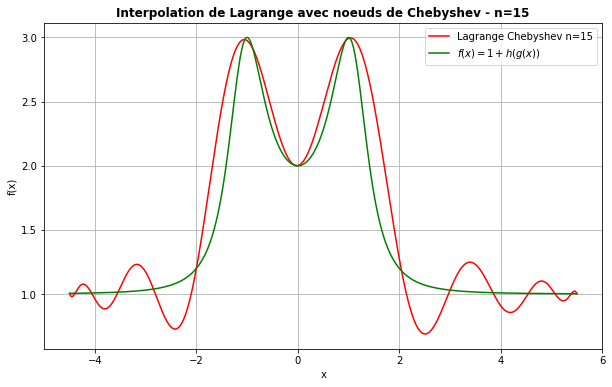

In [9]:
a = -4.5; b = 5.5
x = np.linspace(a,b,1000) # fine partition, for nice plotting 
n=15

# >>> COMPLETE HERE <<<
# 1. Create the Chebyschev nodes in the interval [-1,1]
# 2. Rescale the nodes to the interval [a,b]
# 3. Interpolate

hx = -np.cos(np.pi*np.linspace(0,n,n+1)/n)
t =(a+b)/2 + (b-a)/2*hx
fn = LagrangeInterpolation(t,f(t),x)

plt.figure(figsize=(10,6))
plt.plot(x, fn, 'r', x, f(x), 'g')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend([f"Lagrange Chebyshev n={n}", '$ f(x)=1+h(g(x)) $'])
plt.grid()
plt.title(f"Interpolation de Lagrange avec noeuds de Chebyshev - n={n}", fontweight="bold")
plt.show()

Calculer les erreurs absolue et relative sur l'intervalle $I$ avec des noeuds équidistribués pour $n=5,\cdots,50$ et visualizer le graphe logarithmique de l'erreur en fonction de $n$.

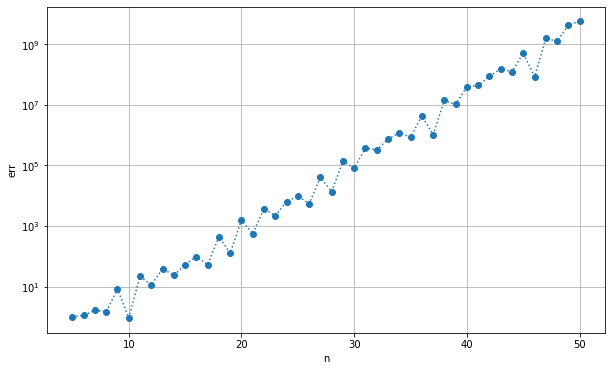

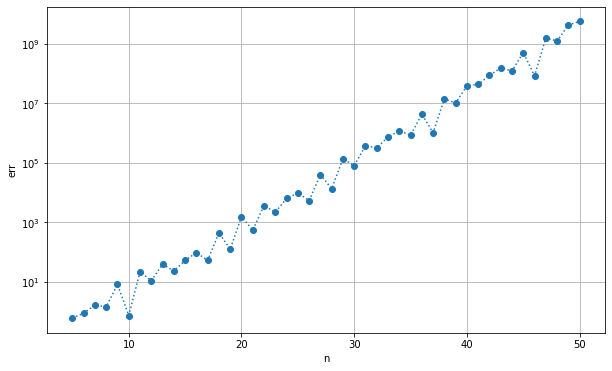

In [14]:
Nrange = np.arange(5,51) 
errorLag = [] # absolute error
errorLagRel = [] # relative error
for n in Nrange:
    # >>> COMPLETE HERE <<<
        # >>> COMPLETE HERE <<<
    # Define the equispaced nodes for the current degree
    # Interpolate
    # Compute the errors
    
    t = np.linspace(a,b,n+1)
    fn = LagrangeInterpolation(t,f(t),x)
    
    errorLag.append( np.max(np.abs(f(x)-fn)) ) # to complete!
    errorLagRel.append( np.max( np.abs(f(x)-fn)/np.abs(f(x)) ) ) # to complete!
    
plt.figure(figsize=(10,6))
plt.plot(Nrange, errorLag, ':o')
plt.yscale("log")
plt.xlabel('n')
plt.ylabel('err')
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(Nrange, errorLagRel, ':o')
plt.yscale("log")
plt.xlabel('n')
plt.ylabel('err')
plt.grid()
plt.show()

Calculer les erreurs absolue et relative sur l'intervalle $I$ avec les noeuds de Chebyshev pour $n=5,\cdots,50$ et visualizer le graphe logarithmique de l'erreur en fonction de $n$.

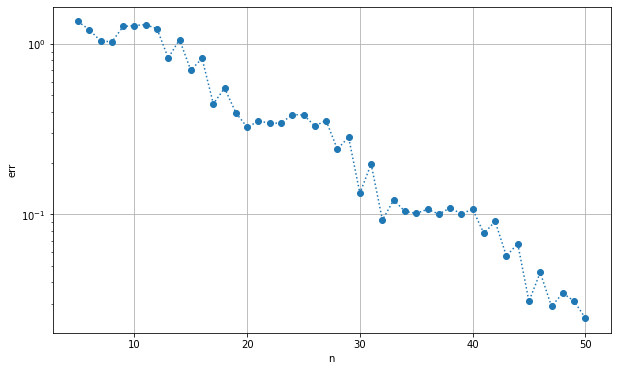

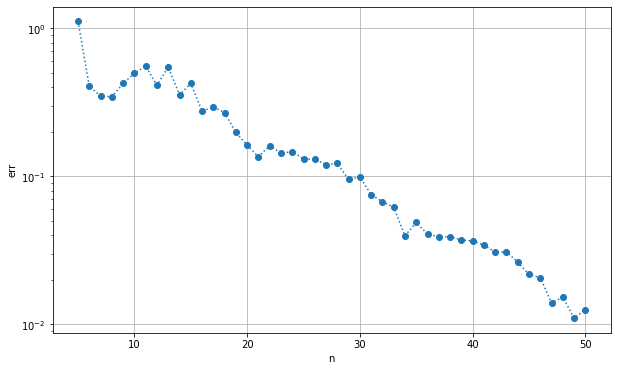

In [13]:
Nrange = np.arange(5,51)
errorChe = [] # absolute error
errorCheRel = [] # relative error
for n in Nrange:
    # >>> COMPLETE HERE <<<
    # Define the Chebyshev nodes for the current degree
    # Interpolate
    # Compute the errors

    hx = -np.cos(np.pi*np.linspace(0,n,n+1)/n)
    t =(a+b)/2 + (b-a)/2*hx 
    fn = LagrangeInterpolation(t,f(t),x)
    
    errorChe.append(np.max(np.abs(f(x)-fn))) # to complete!
    errorCheRel.append(np.max( np.abs(f(x)-fn)/np.abs(f(x)) )) # to complete!

plt.figure(figsize=(10,6))
plt.plot(Nrange, errorChe, ':o')
plt.yscale('log')
plt.xlabel('n')
plt.ylabel('err')
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(Nrange, errorCheRel, ':o')
plt.yscale('log')
plt.xlabel('n')
plt.ylabel('err')
plt.grid()
plt.show()

### Partie 2

Tracer le graphe de la fonction et de ses polynômes d'interpolation linéaires par intervalles avec $N=[5, 10, 20, 40]$ sous-intervalles.

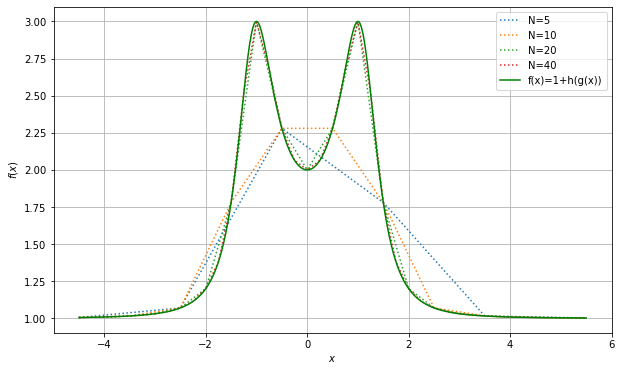

In [20]:
plt.figure(figsize=(10,6))

x = np.linspace(a,b,1000)

Nrangeplot = [5,10,20,40]
for n in Nrangeplot: 
    # >>> COMPLETE HERE <<<
    # Interpolate

    z = np.linspace(a,b,n+1)
    fn = PiecewiseLinearInterpolation(a,b,n,f(z),x)
    
    plt.plot(x, fn, ':', label=f"N={n}")

plt.plot(x, f(x), 'g', label="f(x)=1+h(g(x))")
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.grid()
plt.legend()
plt.show()

Calculer les erreurs absolue et relative en considerant $N=[5,\cdots,50]$ sous-intervalles et visualiser le graphe logarithmique de l'erreur en fonction de $N$.

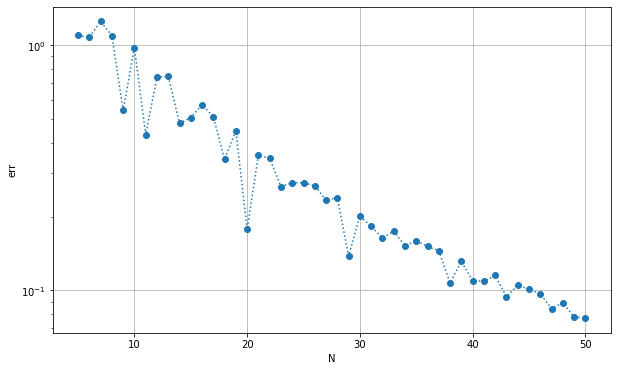

In [24]:
Nrange = np.arange(5,51)
errorLin = [] # absolute error
errorLinRel = [] # relative error
for n in Nrange: 
    # >>> COMPLETE HERE <<<
    # 1. Interpolate
    # 2. Compute the errors

    z = np.linspace(a,b,n+1)
    fn = PiecewiseLinearInterpolation(a,b,n,f(z),x)

    errorLin.append( np.max(np.abs(f(x)-fn)) ) # to complete!
    errorLinRel.append( np.max( np.abs(f(x)-fn)/np.abs(f(x)) ) ) # to complete!

plt.figure(figsize=(10,6))
plt.plot(Nrange, errorLin, ':o')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('err')
plt.grid()
plt.show()

Tracer le graphe de la fonction et de ses polynômes d'interpolation quadratiques par intervalles avec $N=[5, 10, 20, 40]$ sous-intervalles.

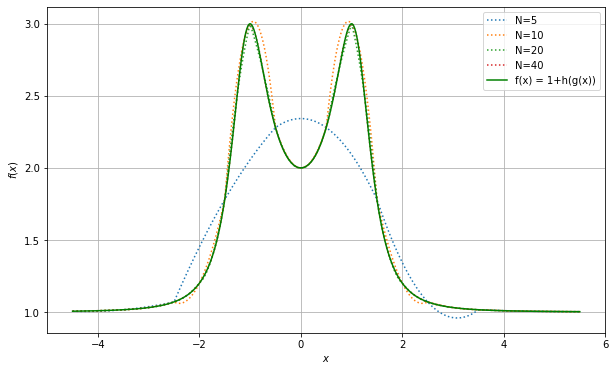

In [23]:
plt.figure(figsize=(10,6))

x = np.linspace(a,b,1000)

Nrangeplot = [5,10,20,40]
for n in Nrangeplot: 
    # >>> COMPLETE HERE <<<
    # Interpolate

    z = np.linspace(a,b,n+1)
    fn = PiecewiseQuadraticInterpolation(a,b,n,f,x)
    
    plt.plot(x, fn, ':', label=f"N={n}")

plt.plot(x, f(x), 'g', label="f(x) = 1+h(g(x))")
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.grid()
plt.legend()
plt.show()

Calculer les erreurs absolue et relative en considerant $N=[5,\cdots,50]$ sous-intervalles et visualiser le graphe logarithmique de l'erreur en fonction de $N$.

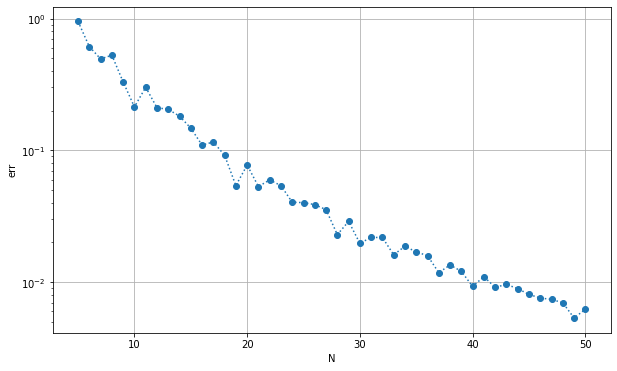

In [26]:
Nrange = np.arange(5,51)
errorQuad = [] # absolute error
errorQuadRel = [] # relative error
for n in Nrange: 
    # >>> COMPLETE HERE <<<
    # 1. Interpolate
    # 2. Compute the errors

    z = np.linspace(a,b,n+1)
    fn = PiecewiseQuadraticInterpolation(a,b,n,f,x)
    
    errorQuad.append(np.max(np.abs(f(x)-fn))) # to complete!
    errorQuadRel.append(np.max( np.abs(f(x)-fn)/np.abs(f(x)) )) # to complete!

plt.figure(figsize=(10,6))
plt.plot(Nrange, errorQuad, ':o')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('err')
plt.grid()
plt.show()

### Partie 3
Comparer les résultats obtenus avec les quatre methodes, à l'aide d'une graphe logarithmique des erreurs relatives.

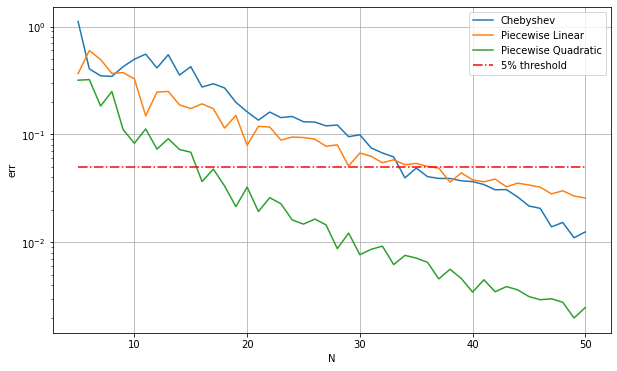

In [27]:
plt.figure(figsize=(10,6))

# plt.plot(Nrange, errorLagRel,  label = 'Lagrange')
plt.plot(Nrange, errorCheRel,  label = 'Chebyshev')
plt.plot(Nrange, errorLinRel,  label = 'Piecewise Linear') 
plt.plot(Nrange, errorQuadRel, label = 'Piecewise Quadratic') 

tol = 0.05
plt.plot(Nrange, tol*np.ones(len(Nrange)), 'r-.', label='5% threshold')

plt.yscale('log')
plt.xlabel('N')
plt.ylabel('err')
plt.legend()
plt.grid()
plt.show()

**Commenter les résultats, en répondant aux questions suivantes**.

* **Qu'est-ce qui se passe en utilisant des noeuds équidistribués? Pourquoi?**
* **Est-ce que l'erreur diminue en considerant des noeuds differents? Pourquoi?**
* **Est-ce que l'erreur diminue en utilisant l'interpolation par intervalles? Pourquoi?**
* **Quelle(s) méthode(s) choisisseriez-vous pour interpoler la fonction donnée avec une erreur relative au plus de 5%? Pourquoi?**

- L'interpolation présente des grandes oscillations au voisinage des extérmités de l'intervalle. A ces endroits, l'erreur augmente au lieu de diminuer pour des grand degré : c'est l'effet de Runge. L'erreur peut augmenter si la dérivée (n+1)ième de la fonction explose sur l'intervalle.

- Oui. L'erreur diminue en utilisant les noeuds de Chebyshev car cet échantillonage minimise l'effet de Runge.

- Oui. Plus on prend de sous-intervalles, plus ils seront petits et moins le polynome interpolant peut présenter des oscillations et donc plus il convergera.

- En utilisant l'interpolation quadratiqur par parties, dès le 15ème degré, l'erreur est inferieure a 5% ce qui donne une meilleure approximation.  

### Partie 4 [Bonus]

Soit $m \geq 0$ un nombre entier. Etant donnés <font color=red>$(n+1)$ points</font>  ~~distincts~~ $x_0$, $x_1$,$\dots$ $x_n$ et $(n+1)$ valeurs $y_0$, $y_1$,$\dots$ $y_n$, on cherche un polynôme $p$ <font color=red>de degré $m<n$</font>, tel que

$$\sum_{j=0}^n |y_j - p(x_j)|^2 \qquad \text{ soit le plus petit possible}.$$

On appelle **polynôme aux moindres carrés de degré $m$** le polynôme $\hat{p}_n(x)$ de degré $m$ tel que
\begin{equation}
  \sum_{j=0}^n |y_j - \hat{p}_n(x_j)|^2 \leq \sum_{j=0}^n |y_j - p_n(x_j)|^2
  \qquad \forall p_m(x) \in \mathbb{P}_m
\end{equation}

Nous cherchons les coefficients du polynôme $p(x) = a_0 + a_1 x + ... + a_m x^m$ qui satisfait *au mieux* les $(n+1)$ équations $p(x_k) = y_k, k=0,...,n$, c'est-à-dire

$$a_0 + a_1 x_k + ... + a_m x_k^m = y_k \qquad k=0,...,n$$

Ce système s'écrit sous forme matricielle 

$$\begin{pmatrix}
1 & x_0 & \cdots & x_0^m \\
\vdots   &   &  & \vdots \\
1 & x_n & \cdots & x_n^m
\end{pmatrix}
\begin{pmatrix} a_0 \\ \vdots \\ a_m \end{pmatrix}
=\begin{pmatrix} y_0 \\ \vdots \\ y_n \end{pmatrix}$$

Puisque $m<n$, on ne peut pas résoudre ce système de façon classique parce qu'on a un nombre d'equations ($n$) qui est superieur au nombre d'inconnues ($m$). Il faut le résoudre *au sens des moindres carrés*, c'est-à-dire on cherche $\mathbf{a}\in\mathbb{R}^{n+1}$ tel que:
$$B^T B \mathbf{a} = B^T \mathbf{y}$$
où $B$ est la matrice $(m+1)\times(n+1)$ du système et $\mathbf{y}\in\mathbb{R}^{m+1}$ le vecteur des données.

Ce système linéaire est dit **système d'équations normales**. On peut montrer que les équations normales sont équivalentes au problème de minimisation.

**Remarque:** *La résolution de ce système linéaire demande parfois des méthodes plus avancées que l'élimination de Gauss, comme par example la factorisation QR. Pour l'instant on va se contenter d'utiliser la fonction* `np.linalg.solve`

Pour construire cette matrice, vous pouvez utiliser la fonction
```python
def VandermondeMatrix(x, m=0):
    # Input
    # x : +1 array with interpolation nodes
    # m : degree of the polynomial. If empty, chooses m=size(x)-1 
    # Output
    # Matrix of Vandermonde of size m x n
```
qui a été deja importé au début du notebook avec la commande
```python
from InterpolationLib import VandermondeMatrix 
```

### Exercice
Evaluer la fonction donnée en $n=101$ points équidistribués sur $I$. Ensuite approchez la fonction avec la méthode des moindres carrées de degré $m=0,1,5,10,20,30,40,50$. 

ValueError: shapes (1,101) and (1000,) not aligned: 101 (dim 1) != 1000 (dim 0)

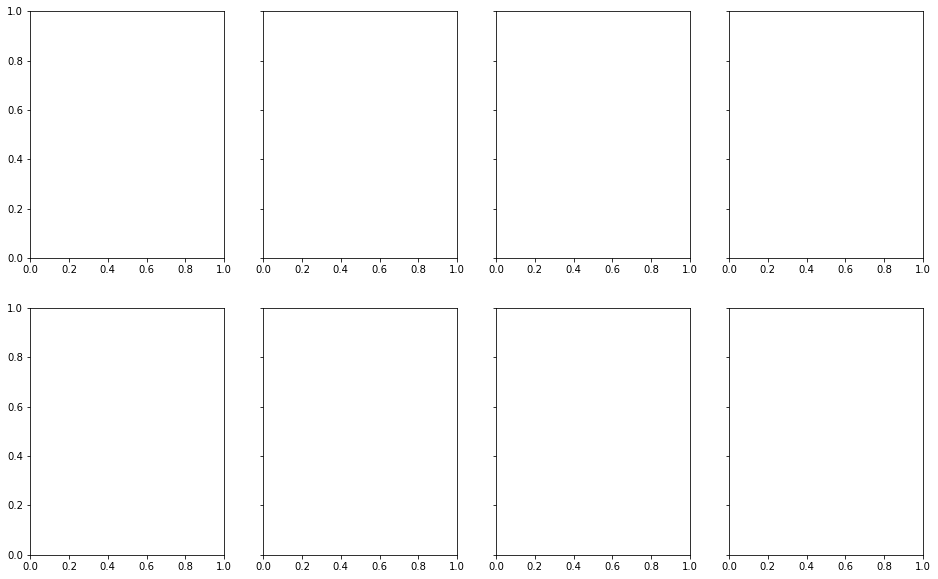

In [34]:
orders = [0,1,5,10,20,30,40,50]
errorMC = []
errorMCRel = []

x_eval = np.linspace(a,b,101)
x = np.linspace(a,b,1000) # fine partition, for nice plotting 

fig, axs = plt.subplots(2,len(orders)//2, figsize=(16,10), sharey=True)

cnt = 0
for m in orders:
    B = VandermondeMatrix(x_eval,m=m)

    # >>> COMPLETE HERE <<<
    # 1. Compute the matrix and the vector of the linear system
    # 2. Solve the linear system

    B2 = np.linalg.inv(np.dot(B.T,B))
    sol = np.dot(B2,np.dot(np.dot(B2,B.T),f(x)))
    
    # this is the function approximation, evaluated in 1000 equispaced points
    pol = np.polyval(np.flip(sol), x)  
    
    # 3. Compute the errors
    
    errorMC.append(0)  # to complete!
    errorMCRel.append(0) # to complete!
    
    axs[cnt%2, cnt//2].plot(x, f(x), label='f(x)')
    axs[cnt%2, cnt//2].plot(x, pol, ':', label=f'MC - m={m}')
    axs[cnt%2, cnt//2].plot(x_eval, f(x_eval), 'r*', markersize=1, label='f(x_eval)')
    axs[cnt%2, cnt//2].set_xlabel('$x$')
    axs[cnt%2, cnt//2].set_ylabel('$f(x)$')
    axs[cnt%2, cnt//2].set_title(f"MC - m={m}", fontweight="bold")
    axs[cnt%2, cnt//2].grid()
    axs[cnt%2, cnt//2].legend(fontsize=9, loc='upper left')
    
    print(f"Order {m}. Absolute error: {errorMC[-1]:.2e}; Relative error: {errorMCRel[-1]:.2e}")
    
    cnt += 1
    
plt.show()

ValueError: x and y must have same first dimension, but have shapes (8,) and (0,)

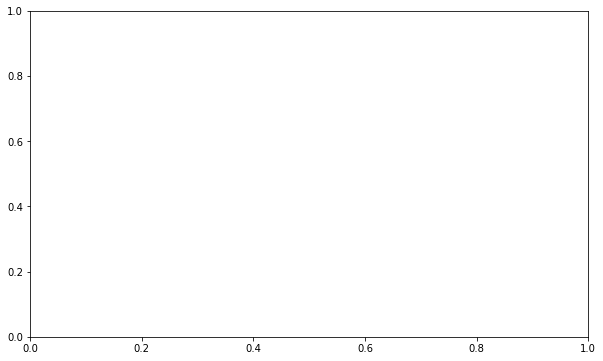

In [29]:
plt.figure(figsize=(10,6))
plt.plot(orders, errorMCRel, '-o')
plt.xlabel("Order")
plt.ylabel("Relative Error")
plt.grid()
plt.show()